# Tarea Semanal 3: Simulación de un ADC (cuantización) parte 1/2
**Autor:** Marco Trabattoni  
**Cátedra:** Procesamiento Digital de Señales - R6051  
**Docente:** Mariano Llamedo Soria
 
---
## 1. Introducción

En esta tarea simularemos el comportamiento de un **ADC** y cómo sus parámetros, tamaño de palabra de **B** bits y frecuencia de muestreo **fs** afectan a una señal (aproximadamente) analógica.

Para ello se puede analizar una **senoidal** con los siguientes parámetros:

* frecuencia $f_0$ arbitraria, por ejemplo $f_0 = f_s / N = \Delta_f$,
* **Potencia normalizada**, es decir unitaria.

Se pide diseñar un bloque *cuantizador* que opere sobre una señal discreta en tiempo $s_R$, de forma tal que para un ADC de B bits y rango $V_{FS} = 2 \cdot V_F$, el operador:

$$s_Q = \underset{B, V_{FS}}{Q} \{s_R\}$$

generará una $s_Q$ comprendida entre $\pm V_F$ y con valores discretos establecidos por el paso de cuantización $q = \frac{V_{FS}}{2^B}$ (Volts).

Visualice en una misma gráfica $s_R$ y $s_Q$, donde se pueda observar que tienen **el mismo rango** en Volts y el efecto de la cuantización para $V_F = 2$ Volts y $B = 4, 8$ y $16$ bits.

### **Bonus:**

* 🤯 Analizar la señal de error $e = s_Q - s_R$ verificando las descripciones estadísticas vistas en teoría (Distribución uniforme, media, varianza, incorrelación).



## 2. Configuración
En esta sección se importan las librerías necesarias (`numPy` y `matplotlib.pyplot`) y se definen tanto los algoritmos de trabajo, como los parámetros globales de la simulación (frecuencia de muestreo, frecuencias de las señales, bits del ADC, etc).

In [12]:
# Importación de módulos que utilizaremos en esta tarea semanal 3:
import matplotlib.pyplot as plt
import numpy as np

#%%  ALGORITMO DFT
def mi_funcion_DFT(xx):
    N = len(xx)
    n = np.arange(N)
    k = n.reshape((N, 1))
    
    matriz_exponencial = np.exp(-2j * np.pi * k * n / N)
    
    XX = np.dot(matriz_exponencial, xx)
    
    return XX

#%% Cuantizador
def cuantizador(Xd, B, Vf):
    Vfs = 2 * Vf
    q = Vfs / (2**B) 
    
    Xq = np.round(Xd / q) * q
    
    Xq = np.clip(Xq, -Vf, Vf - q)
    
    return Xq


#%%  Definicion de mi señal senoidal (TS1)
# Agregamos el parámetro opcional 'con_ruido' para contrastar lo pedido por la cátedra
def MT_Senoidal(vmax=1, dc=0, ff=1, ph=0, nn=100, fs=100, con_ruido=True):
    
    """
    Genera una señal senoidal con los siguientes argumentos:
        
    vmax -- Amplitud máxima (Volts)
    dc   -- Valor medio (Volts)
    ff   -- Frecuencia de la senoidal (Hz)
    ph   -- Fase (Radianes)
    nn   -- Cantidad de muestras (#)
    fs   -- Frecuencia de muestreo (Hz)
    
    Retorna:
    tt   -- Vector de tiempo (Nx1)
    xx   -- Vector de amplitud (Nx1)
    
    """
    
    # Calculamos el intervalo entre muestras (periodo de muestreo)
    ts = 1/fs
    
    # Generamos el vector de tiempo tt
    tt = np.arange(0.0, nn*ts, ts)
    
    # Generamos el vector de señal xx (con o sin ruido analógico)
    if con_ruido:
        ruido_analogico = 0.125 * np.random.randn(len(tt))
    else:
        ruido_analogico = 0.0
        
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc + ruido_analogico
    
    return tt, xx


#%% Parámetros
VF = 2
fs = 1000
N = 1000
f0 = 4

# Mantenemos tus señales originales intactas (con ruido analógico de pre-cuantización)
t, Xr  = MT_Senoidal(vmax=np.sqrt(2), dc=0, ff=f0, ph=0, nn=N, fs=fs, con_ruido=True)

# Generamos en paralelo la señal PURA para cumplir la corrección de Mariano sobre correlación
_, Xr_pura = MT_Senoidal(vmax=np.sqrt(2), dc=0, ff=f0, ph=0, nn=N, fs=fs, con_ruido=False)

bits_list = [4, 8, 16]

## 3. Generación y Visualización de Señales
Se procede a instanciar las señales utilizando las funciones definidas anteriormente y se grafican para verificar su correcto funcionamiento en el dominio del tiempo. 

Para evaluar el efecto del tamaño de palabra (B) en la cuantización, o sea, el impacto de la resolución del ADC, se procesa una señal determinística contaminada por un piso de ruido analógico preexistente. El rango dinámico del cuantizador está fijado por $V_f = \pm 2\text{ V}$ ($V_{fs} = 4\text{ V}$). 

El paso de cuantización (amplitud del escalón) se define analíticamente como: $$q = \frac{V_{fs}}{2^B}$$

A continuación, se grafica la señal original $X_r$ frente a su versión cuantizada $X_q$ para tamaños de palabra de $B = 4$, $B = 8$ y $B = 16$ bits, exponiendo de forma visual cómo disminuye el error de redondeo a medida que incrementamos la densidad de niveles disponibles.

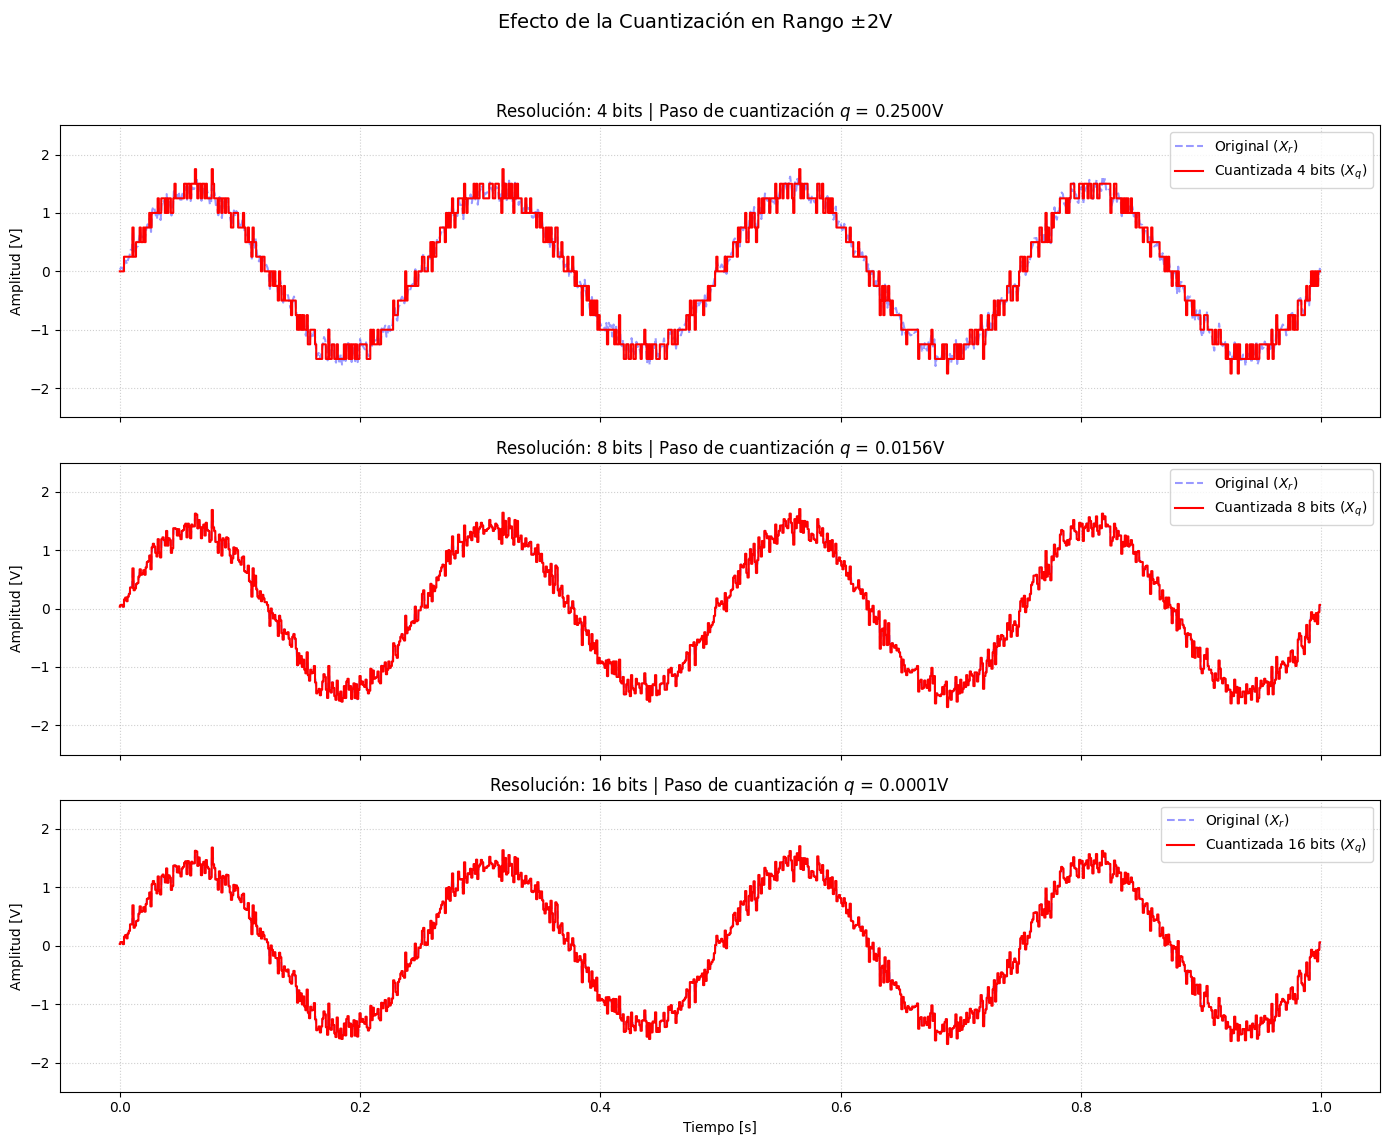

In [13]:
#%% --- Gráfica 1 ---
fig, axs = plt.subplots(len(bits_list), 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'Efecto de la Cuantización en Rango $\pm${VF}V', fontsize=14)

for i, B in enumerate(bits_list):
    Xq = cuantizador(Xr, B, VF)
    q = (2 * VF) / (2**B)
    
    # Graficamos la original y la cuantizada en cada subplot
    axs[i].plot(t, Xr, label='Original ($X_r$)', alpha=0.4, color='blue', linestyle='--')
    axs[i].step(t, Xq, label=f'Cuantizada {B} bits ($X_q$)', where='mid', color='red')
    
    # Detalles estéticos
    axs[i].set_title(f'Resolución: {B} bits | Paso de cuantización $q$ = {q:.4f}V')
    axs[i].set_ylabel('Amplitud [V]')
    axs[i].set_ylim(-VF - 0.5, VF + 0.5) # Mismo rango para todos
    axs[i].grid(True, linestyle=':', alpha=0.6)
    axs[i].legend(loc='upper right')

axs[-1].set_xlabel('Tiempo [s]')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Conclusión de Resultados

* **B = 4 bits ($q = 0.2500\text{ V}$):** La resolución es baja. El efecto de "escalonamiento" es claramente visible a simple vista en el dominio del tiempo. La señal cuantizada pasa gran parte del tiempo saltando entre niveles discretos adyacentes, lo que introduce un error de cuantización grueso de alta energía.
* **B = 8 bits ($q = 0.0156\text{ V}$):** El paso de cuantización se reduce. Visualmente, la señal cuantizada $X_q$ comienza a calcar la trayectoria de la señal analógica original.
* **B = 16 bits ($q = 0.0001\text{ V}$):** A este nivel de resolución (común en aplicaciones de audio de alta fidelidad), la cuantización es imperceptible. El error de redondeo es mínimo que, para los fines prácticos de la visualización, las señales analógica y digitalizada se superponen perfectamente.

## 4. Bonus

En esta sección se analiza la naturaleza estocástica del error de cuantización $e_n = X_q - X_r$ para un tamaño de palabra fijo de $B = 6\text{ bits}$. El objetivo es validar experimentalmente el modelo lineal del ruido de cuantización y verificar si se cumplen las cuatro hipótesis:

1. Media nula ($\mu_e = 0$).
2. Densidad de probabilidad uniforme distribuyendo su energía en el rango $[-q/2, q/2]$.
3. Potencia o varianza teórica equivalente a $\sigma_e^2 = \frac{q^2}{12}$.
4. Incorrelación temporal (comportamiento de ruido blanco).


Se esperan visualizar los siguientes comportamientos cuantitativos y cualitativos:

* **Caso con Ruido Analógico:** La senoidal de entrada arrastra un piso de ruido analógico gaussiano correlativo a un entorno real.
* **Caso Senoidal Pura:** La señal ingresa al ADC de forma ideal y libre de perturbaciones externas.
* **En cuanto a la SNR y Parámetros Estocásticos:** Al estar fijado el tamaño de palabra en $B = 6\text{ bits}$, la relación señal-a-ruido teórica calculada mediante la ecuación clásica de la cátedra debe arrojar un valor exacto.


--- CÁLCULO DE LA SNR (B=6) ---
SNR Medida (Con Ruido Analógico): 35.06 dB
SNR Teórica: 37.88 dB

--- ESTADÍSTICAS DEL ERROR (B=6) ---
Media: -0.000344 (Teórica: 0)
Varianza Medida: 0.000318
Varianza Teórica (q^2/12): 0.000326


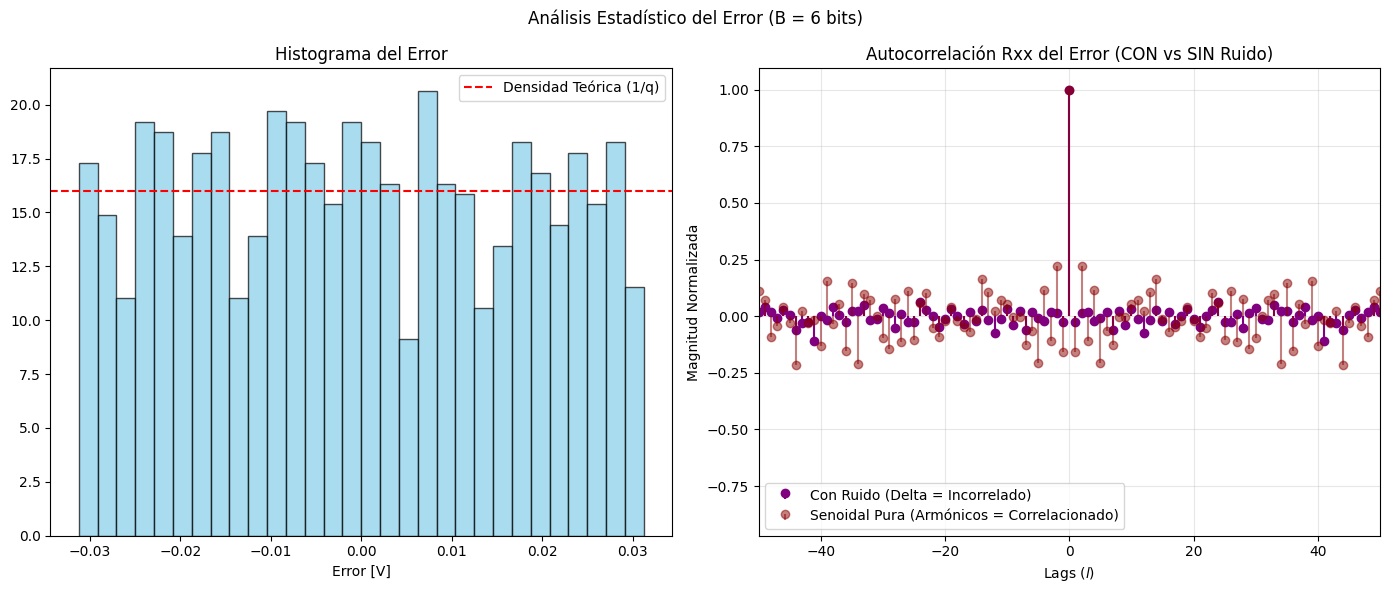

In [14]:
#%% NUEVA SECCIÓN: ANÁLISIS ESTADÍSTICO DEL ERROR (Bonus)
B_analisis = 6
q_analisis = (2 * VF) / (2**B_analisis)

# CASO A (Tu original): Error con ruido analógico de fondo
Xq_analisis = cuantizador(Xr, B_analisis, VF)
error = Xq_analisis - Xr

# CASO B (Agregado para Mariano): Error sobre la senoidal pura
Xq_pura = cuantizador(Xr_pura, B_analisis, VF)
error_puro = Xq_pura - Xr_pura


#%% --- CÁLCULO DE SNR ---
potencia_señal = np.var(Xr)  # Si tiene media 0, la varianza es la potencia
potencia_ruido = np.var(error)

snr_medida = 10 * np.log10(potencia_señal / potencia_ruido)

# SNR Teórica para un ADC (6.02*B + 1.76 dB)
snr_teorica = 6.02 * B_analisis + 1.76

print(f"\n--- CÁLCULO DE LA SNR (B={B_analisis}) ---")
print(f"SNR Medida (Con Ruido Analógico): {snr_medida:.2f} dB")
print(f"SNR Teórica: {snr_teorica:.2f} dB")

#%% Cálculos de Media y Varianza
media_e = np.mean(error)
var_e_medida = np.var(error)
var_e_teorica = (q_analisis**2) / 12

print(f"\n--- ESTADÍSTICAS DEL ERROR (B={B_analisis}) ---")
print(f"Media: {media_e:.6f} (Teórica: 0)")
print(f"Varianza Medida: {var_e_medida:.6f}")
print(f"Varianza Teórica (q^2/12): {var_e_teorica:.6f}")


#%% Gráficas de distribución e incorrelación
# Cambiamos figsize=(14, 6) para que use todo el horizontal
fig_error, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig_error.suptitle(f'Análisis Estadístico del Error (B = {B_analisis} bits)')

# Histograma para ver la Distribución Uniforme
ax1.hist(error, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axhline(1/q_analisis, color='red', linestyle='--', label=f'Densidad Teórica (1/q)')
ax1.set_title('Histograma del Error')
ax1.set_xlabel('Error [V]')
ax1.legend()

# --- CORRECCIÓN CRÍTICA DE MARIANO: COMPARATIVA DE AUTOCORRELACIÓN ---
# Calculamos la autocorrelación del error con ruido analógico
autocorr_ruidosa = np.correlate(error - media_e, error - media_e, mode='full')
autocorr_ruidosa = autocorr_ruidosa / np.max(autocorr_ruidosa)

# Calculamos en paralelo la autocorrelación del error de la senoidal pura
autocorr_pura = np.correlate(error_puro - np.mean(error_puro), error_puro - np.mean(error_puro), mode='full')
autocorr_pura = autocorr_pura / np.max(autocorr_pura)

lags = np.arange(-len(error) + 1, len(error))

# En este ax2 graficamos AMBAS autocorrelaciones para evidenciar la delta
# Caso A: Con ruido analógico (Normal)
ax2.stem(lags, autocorr_ruidosa, linefmt='purple', markerfmt='purple', basefmt=' ', label='Con Ruido (Delta = Incorrelado)')

# Caso B: Senoidal pura (Solución al error aplicando plt.setp para el alpha)
markerline, stemlines, baseline = ax2.stem(lags, autocorr_pura, linefmt='darkred', markerfmt='darkred', basefmt=' ', label='Senoidal Pura (Armónicos = Correlacionado)')
plt.setp(markerline, alpha=0.5)
plt.setp(stemlines, alpha=0.5)

ax2.set_xlim(-50, 50) # Zoom clave en lags centrales
ax2.set_title('Autocorrelación Rxx del Error (CON vs SIN Ruido)')
ax2.set_xlabel('Lags ($l$)')
ax2.set_ylabel('Magnitud Normalizada')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusiones

El histograma del error corrobora la hipótesis de distribución uniforme. Al superponerse la línea de densidad teórica $1/q$, se comprueba que el error de redondeo del ADC se reparte equitativamente a lo largo de todo el escalón de cuantización, comportándose como una variable aleatoria bien distribuida.

Al inspeccionar el gráfico de autocorrelación $R_{xx}$ para el caso con ruido analógico (líneas púrpuras), se observa una **Delta de Kronecker** perfecta localizada en el retardo cero ($l=0$), extinguiéndose en el resto de los lags. Esto demuestra que la preexistencia de un piso de ruido analógico actúa matemáticamente como un *dither* natural, rompiendo el determinismo de la senoidal y forzando a que el error de cuantización sea un proceso estocástico totalmente incorrelacionado (ruido blanco).

En contraposición, al remover el ruido de entrada y evaluar la senoidal pura (líneas rojas con transparencia), el gráfico de autocorrelación revela picos armónicos periódicos y destructivos fuera del origen. Esto evidencia que el error de redondeo ya no es aleatorio, sino que está fuertemente correlacionado con la señal de entrada. En este escenario, **las hipótesis de ruido blanco fallan**, y el efecto del ADC se manifiesta estrictamente como **distorsión armónica por cuantización**.

## 5. Análisis Frecuencial

Se traslada la señal de error $e_n$ al dominio de la frecuencia calculando su Transformada Discreta de Fourier mediante el algoritmo propio `mi_funcion_DFT`. 

La distribución de la energía en el espectro debe reflejar directamente el grado de correlación que determinamos en la sección anterior:

Para el caso con Ruido Analógico: Como la autocorrelación colapsó en una delta (máxima incorrelación), se espera un espectro de magnitud plano y denso. La energía del error debe distribuirse de manera equitativa por todo el espectro, comportándose analíticamente como un Ruido Blanco de Cuantización.

Para el caso de una Senoidal Pura: Al no haber aleatoriedad que rompa el determinismo de la entrada, el error es periódico. Por ende, se espera que la energía espectral no sea plana, sino que se concentre con gran magnitud en armónicos ubicados en múltiplos de la frecuencia fundamental $f_0$. Esto confirmará que el fenómeno físico presente en un ADC sin distorsión Armónica por Cuantización.

A continuación, se grafica una ventana temporal en zoom para apreciar el comportamiento de los escalones y se superponen ambos espectros calculados para contrastar de forma directa sus diferencias.

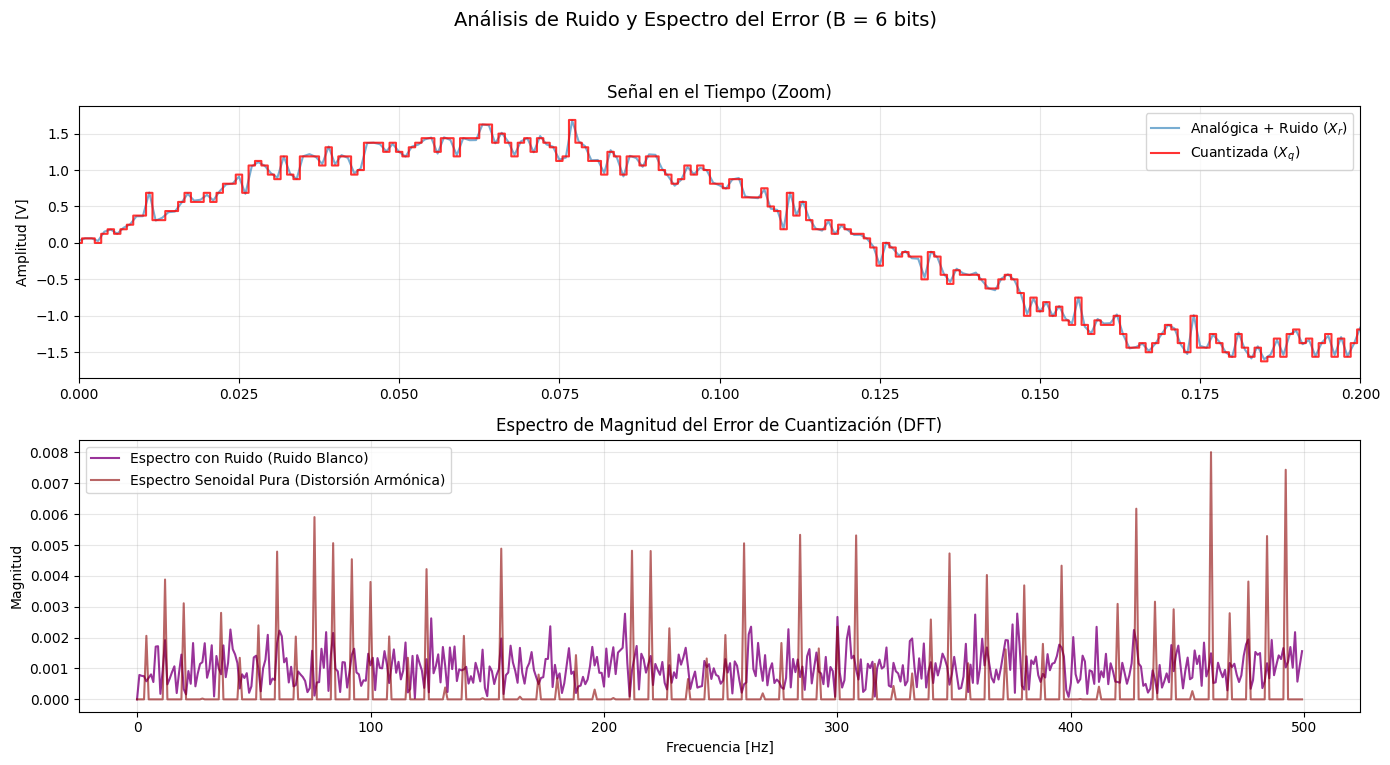

In [15]:
#%% --- CÁLCULO DEL ESPECTRO DEL ERROR (DFT) ---
df = fs / N 

# Calculamos el espectro de tu señal (Con ruido)
yf_dft = mi_funcion_DFT(error - np.mean(error))
f_eje = np.arange(0, fs, df)    
xf = f_eje[:N//2]
espectro_error = 2.0/N * np.abs(yf_dft[:N//2])

# Calculamos el espectro de la senoidal pura para comparar visualmente
yf_dft_pura = mi_funcion_DFT(error_puro - np.mean(error_puro))
espectro_error_puro = 2.0/N * np.abs(yf_dft_pura[:N//2])


#%% --- GRÁFICAS DE ESPECTRO ---
# Modificado a figsize=(14, 8) para máxima visualización horizontal
fig_bonus, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
fig_bonus.suptitle(f'Análisis de Ruido y Espectro del Error (B = {B_analisis} bits)', fontsize=14)

# Señal en el tiempo (Zoom para ver el ruido)
ax1.plot(t, Xr, label='Analógica + Ruido ($X_r$)', alpha=0.6)
ax1.step(t, Xq_analisis, label='Cuantizada ($X_q$)', where='mid', color='red', alpha=0.8)
ax1.set_xlim(0, 0.2) # Zoom inicial para ver los escalones y el ruido
ax1.set_title('Señal en el Tiempo (Zoom)')
ax1.set_ylabel('Amplitud [V]')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Espectro de Frecuencia del Error (Superponemos ambos espectros para la discusión del informe)
ax2.plot(xf, espectro_error, color='purple', alpha=0.8, label='Espectro con Ruido (Ruido Blanco)')
ax2.plot(xf, espectro_error_puro, color='darkred', alpha=0.6, label='Espectro Senoidal Pura (Distorsión Armónica)')
ax2.set_title('Espectro de Magnitud del Error de Cuantización (DFT)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Magnitud')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 6. Conclusiones Generales

Se demuestra que en entornos reales de adquisición de datos, un piso de ruido analógico moderado (o la inyección controlada de **Distorsión Armónica por Cuantización**) no busca atenuar la potencia total del error de cuantización (la cual sigue fija por los bits del conversor), sino que tiene el objetivo estratégico de "linealizar el ADC", destruyendo las componentes armónicas espurias y distribuyendo uniformemente esa energía a lo largo de todo el espectro de frecuencias, facilitando su posterior filtrado digital.

1. Se comprobó experimentalmente que el incremento en la cantidad de bits ($B$) reduce de forma el paso de cuantización $q = \frac{V_{fs}}{2^B}$, confinando la amplitud del error de redondeo. Mientras que en resoluciones bajas ($B = 4$) el efecto de escalonamiento destruye la forma temporal de la señal, a partir de $B = 16$ el error posee una energía despreciable, aproximándose al comportamiento de un conversor ideal para propósitos prácticos.

2. El análisis estadístico del error para un tamaño de palabra de $6\text{ bits}$ validó que la media del error convergió a valores nulos y su potencia o varianza replicó el valor analítico de $\frac{q^2}{12}$, confirmando que las amplitudes del error se distribuyen de manera uniforme dentro del intervalo de un escalón $\pm q/2$.

3. La presencia de perturbaciones aleatorias a la entrada del ADC descorrelacionó el error de la propia señal senoidal, transformándolo en ruido Blanco de cuantización. Este fenómeno se evidenció en una función de autocorrelación que colapsó en una **Delta de Kronecker** ideal en el origen y en un espectro de magnitud de la DFT plano.

4. Al remover el ruido de entrada, el error de cuantización quedó ligado a la periodicidad de la senoidal, dando correlaciones temporales. En el dominio de la frecuencia, esto se tradujo en **Distorsión Armónica por Cuantización**, lo cual es mucho más perjudicial para sistemas de audio de alta fidelidad o procesamiento de señales biomédicas que un piso de ruido blanco distribuido.
